In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import os
import pandas as pd
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import json
import math
import pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedAreaConfig, SpatiallyEmbeddedRNN, Ablation
from bioplnn.datasets import Mazes
from bioplnn.utils import (
    initialize_dataloader,
)

maze_data_path = "./data/mazes/"
checkpoint_path = "./train/checkpoints/"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)
        self.gap   = nn.AdaptiveAvgPool2d(1)     # <- NEW
        self.fc1   = nn.Linear(128, 512)          # <- 64 channels only
        self.fc2   = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.gap(x)                          # [B, 64, 1, 1]
        x = torch.flatten(x, 1)                  # [B, 64]
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
def load_model_and_config(wandb_name, checkpoint_path):
    """Load model configuration and instantiate models."""
    try:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
    except:
        model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        num_steps = 20
        
    try:
        if full_cfg["model_type"] == "cnn":
            model = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
            classifier = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
        else:
            model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
            classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    except:
        model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
        classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    return model, classifier, num_steps, full_cfg

In [4]:
wandb_name = "fancy-silence-24"
checkpoint = 370

# wandb_name = "glowing-deluge-31"
# checkpoint = 330

# ——— Load model config & instantiate ———
model, classifier, num_steps, cfg = load_model_and_config(wandb_name, checkpoint_path)

# ——— Load checkpoint & weights ———
try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

try:
    state_dict = state_dict["model_state"]
except:
    pass

model.load_state_dict(prepare_rnn_weights(state_dict))
model.eval()
model.to(device)

classifier.load_state_dict(state_dict)
classifier.eval()

/tmp/ipykernel_4145806/2588792163.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locati

SpatiallyEmbeddedClassifier(
  (rnn): SpatiallyEmbeddedRNN(
    (areas): ModuleList(
      (0): SpatiallyEmbeddedArea(
        (out_nonlinearity): Identity()
        (neuron_type_nonlinearity): ModuleList(
          (0-1): 2 x ReLU()
        )
        (convs): ModuleDict(
          (0->0): Sequential(
            (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (0->1): Sequential(
            (0): Conv2d(1, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (1->0): Sequential(
            (0): Conv2dRectify(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (1->1): Sequential(
            (0): Conv2dRectify(8, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (2->0): Sequential(
            (0): Conv2dRectify(4, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
       

In [5]:
coherences = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.5, 0.9]
n_frames = 40
resolution = (128, 128)
correlation = (0.01,0.9)
max_speed = 1
samples_per_epoch = 5000

data_loader, test_loader = initialize_dataloader(
        seed=10, dataset="correlated_dots",
        resolution=resolution, n_frames=n_frames, correlation=correlation, max_speed=max_speed, samples_per_epoch=samples_per_epoch,
        batch_size=128)

In [19]:
excitatory = True
n_frames = 40

num_samples = len(data_loader.dataset) if hasattr(data_loader, 'dataset') else sum(1 for _ in data_loader)
full_activations = np.zeros((num_samples, n_frames, (8 if excitatory else 4), resolution[0], resolution[1]), dtype=np.float32)
full_decisions = []

# # record activations
with torch.no_grad():
    sample_idx = 0
    for batch_inputs, label in tqdm(data_loader):
        # input: (batch_size, channels, H, W)
        batch_size = batch_inputs.shape[0]
        batch_inputs = batch_inputs.to(device)
        batch_output_states, batch_neuron_states, batch_feedback_states = model(batch_inputs)

        activity = model.query_neuron_states(batch_neuron_states, 0, 0 if excitatory else 1).detach().cpu().numpy()
        # activity = batch_output_states[0].detach().cpu().numpy()

        full_activations[sample_idx:sample_idx+batch_size, :, :, :, :] = activity
        sample_idx += batch_size

    # # record decisions
    classifier.to(device)
    for batch_inputs, label in tqdm(data_loader):
        # input: (batch_size, channels, H, W)
        batch_size = batch_inputs.shape[0]
        batch_inputs = batch_inputs.to(device)
        pred = classifier(batch_inputs)
        full_decisions.extend(torch.argmax(pred, dim=-1).detach().tolist())
    full_decisions = np.array(full_decisions)

100%|██████████| 2/2 [00:03<00:00,  1.75s/it]


In [24]:
num_coherence_samples = 256
coherence_activations = {}
coherence_decisions = {}

for coherence in coherences: 
    data_loader, test_loader = initialize_dataloader(
            seed=10, dataset="correlated_dots",
            resolution=resolution, n_frames=n_frames, correlation=coherence, max_speed=max_speed, samples_per_epoch=num_coherence_samples,
            batch_size=128)
    
    activations = np.zeros((num_coherence_samples, n_frames, (8 if excitatory else 4), resolution[0], resolution[1]), dtype=np.float32)
    decisions = []

    # # record activations
    with torch.no_grad():
        sample_idx = 0
        for batch_inputs, label in tqdm(data_loader):
            # input: (batch_size, channels, H, W)
            batch_size = batch_inputs.shape[0]
            batch_inputs = batch_inputs.to(device)
            batch_output_states, batch_neuron_states, batch_feedback_states = model(batch_inputs)

            # activity = model.query_neuron_states(batch_neuron_states, 0, 0 if excitatory else 1).detach().cpu().numpy()
            activity = batch_output_states[0].detach().cpu().numpy()

            activations[sample_idx:sample_idx+batch_size, :, :, :, :] = activity
            sample_idx += batch_size

        # # record decisions
        classifier.to(device)
        for batch_inputs, label in tqdm(data_loader):
            # input: (batch_size, channels, H, W)
            batch_size = batch_inputs.shape[0]
            batch_inputs = batch_inputs.to(device)
            pred = classifier(batch_inputs)
            decisions.extend(torch.argmax(pred, dim=-1).detach().tolist())
        decisions = np.array(decisions)
    
    coherence_activations[coherence] = activations
    coherence_decisions[coherence] = decisions

100%|██████████| 2/2 [00:03<00:00,  1.75s/it]


In [16]:
train_cut = 0.8
train_idx_cut = int(len(full_activations) * train_cut)
train_decisions = full_decisions[:train_idx_cut]
test_decisions = full_decisions[train_idx_cut:]

C_grid = [0.01, 0.1, 1, 3]
best_C_per_t = []

results = {}

for channel_idx in range(8):
    results[channel_idx] = {}
    for frame_num in [39]:
        results[channel_idx][frame_num] = {}
        print(frame_num)
        train_acts = full_activations[:train_idx_cut, frame_num, channel_idx]
        test_acts = full_activations[train_idx_cut:, frame_num, channel_idx]
        train_acts = train_acts.reshape(train_acts.shape[0], -1)
        test_acts = test_acts.reshape(test_acts.shape[0], -1)

        # tune C on pooled val
        # best_C, best_acc = None, -np.inf
        # for C in C_grid:
        #     clf = LogisticRegression(penalty='l2', C=C, solver='lbfgs', max_iter=2000)
        #     clf.fit(train_acts, train_decisions)
        #     y_hat = clf.predict(test_acts)
        #     n_correct = (y_hat == test_decisions).sum()    
        #     acc = n_correct / len(test_decisions)
        #     if acc > best_acc: best_acc, best_C = acc, C
        # best_C_per_t.append(best_C)

        best_C = 1

        clf = LogisticRegression(penalty='l2', C=best_C, solver='lbfgs', max_iter=2000)
        clf.fit(train_acts, train_decisions)
        y_hat = clf.predict(test_acts)
        n_correct = (y_hat == test_decisions).sum()    
        acc = n_correct / len(test_decisions)
        print(acc)
        results[channel_idx][frame_num]["full"] = acc

        for coherence in coherences:
            print(coherence)
            test_acts = coherence_activations[coherence][:, frame_num, channel_idx]
            test_acts = test_acts.reshape(test_acts.shape[0], -1)
            test_decs = coherence_decisions[coherence]
            y_hat = clf.predict(test_acts)
            n_correct = (y_hat == test_decs).sum()    
            acc = n_correct / len(test_decs)
            print(acc)
            results[channel_idx][frame_num][coherence] = acc

39
0.038461538461538464
0.01
0.12109375
0.02
0.0859375
0.03
0.09375
0.05
0.1015625
0.1
0.12890625
0.2
0.10546875
0.5
0.09375
0.9
0.15625
39
0.09615384615384616
0.01
0.09375
0.02
0.125
0.03
0.078125
0.05
0.08984375
0.1
0.12109375
0.2
0.12890625
0.5
0.12890625
0.9
0.17578125
39
0.11538461538461539
0.01
0.1328125
0.02
0.1171875
0.03
0.140625
0.05
0.15234375
0.1
0.12890625
0.2
0.125
0.5
0.14453125
0.9
0.19140625
39
0.11538461538461539
0.01
0.09765625
0.02
0.08984375
0.03
0.0859375
0.05
0.08984375
0.1
0.12109375
0.2
0.125
0.5
0.1484375
0.9
0.13671875
39
0.09615384615384616
0.01
0.109375
0.02
0.125
0.03
0.1328125
0.05
0.15234375
0.1
0.11328125
0.2
0.1171875
0.5
0.109375
0.9
0.1875
39
0.11538461538461539
0.01
0.09765625
0.02
0.1171875
0.03
0.1171875
0.05
0.1171875
0.1
0.14453125
0.2
0.09765625
0.5
0.140625
0.9
0.1796875
39
0.07692307692307693
0.01
0.0859375
0.02
0.11328125
0.03
0.08203125
0.05
0.08203125
0.1
0.109375
0.2
0.11328125
0.5
0.12890625
0.9
0.1640625
39
0.1346153846153846
0.01
0.125

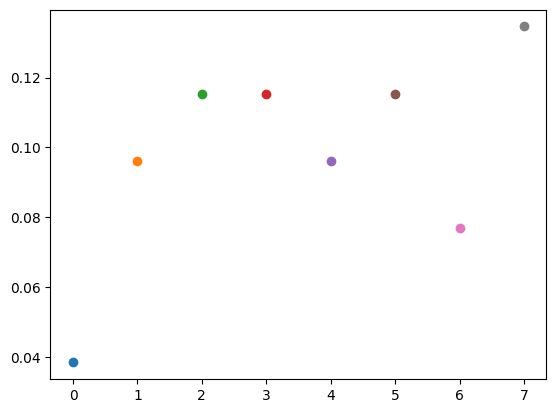

In [17]:
for channel_idx in range(8):
    plt.scatter(channel_idx, results[channel_idx][39]["full"])

In [26]:
train_cut = 0.8
train_idx_cut = int(len(full_activations) * train_cut)
train_decisions = full_decisions[:train_idx_cut]
test_decisions = full_decisions[train_idx_cut:]

C_grid = [0.01, 0.1, 0.3, 1, 3, 10]
best_C_per_t = []

results = {}

for frame_num in [39]:
    results[frame_num] = {}
    print(frame_num)
    train_acts = np.mean(full_activations[:train_idx_cut, frame_num], axis=2)
    test_acts = np.mean(full_activations[train_idx_cut:, frame_num], axis=2)
    train_acts = train_acts.reshape(train_acts.shape[0], -1)
    test_acts = test_acts.reshape(test_acts.shape[0], -1)

    best_C, best_acc = None, -np.inf
    for C in C_grid:
        clf = LogisticRegression(penalty='l2', C=C, solver='lbfgs', max_iter=10000)
        clf.fit(train_acts, train_decisions)
        y_hat = clf.predict(test_acts)
        n_correct = (y_hat == test_decisions).sum()    
        acc = n_correct / len(test_decisions)
        if acc > best_acc: best_acc, best_C = acc, C
    best_C_per_t.append(best_C)

    clf = LogisticRegression(penalty='l2', C=best_C, solver='lbfgs', max_iter=10000)
    clf.fit(train_acts, train_decisions)
    y_hat = clf.predict(test_acts)
    n_correct = (y_hat == test_decisions).sum()    
    acc = n_correct / len(test_decisions)
    print(acc)
    results[frame_num]["full"] = acc

    for coherence in coherences:
        print(coherence)
        test_acts = np.mean(coherence_activations[coherence][:, frame_num], axis=2)
        test_acts = test_acts.reshape(test_acts.shape[0], -1)
        test_decs = coherence_decisions[coherence]
        y_hat = clf.predict(test_acts)
        n_correct = (y_hat == test_decs).sum()    
        acc = n_correct / len(test_decs)
        print(acc)
        results[frame_num][coherence] = acc

39
0.15384615384615385
0.01
0.05078125
0.02
0.06640625
0.03
0.0625
0.05
0.10546875
0.1
0.1015625
0.2
0.15625
0.5
0.14453125
0.9
0.09375
